# Dataset Inspection: dataset-labeled-anon-ip.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../../../data/dataset-labeled-anon-ip.csv'

## 1. Load & Basic Info

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape: (1395324, 47)
Memory: 766.7 MB


In [3]:
df.dtypes

Timestamp                      datetime64[ns, UTC+02:00]
SignatureText                                     object
SignatureID                                        int64
SignatureMatchesPerDay                           float64
AlertCount                                         int64
Proto                                              int64
ExtIP                                             object
ExtPort                                            int64
IntIP                                             object
IntPort                                            int64
Similarity                                       float64
Label                                              int64
SCAS                                               int64
AppProtoSimilarity                               float64
DnsRrnameSimilarity                              float64
DnsRrtypeSimilarity                              float64
EmailFromSimilarity                                int64
EmailStatusSimilarity          

In [4]:
df.head()

,Timestamp,SignatureText,SignatureID,SignatureMatchesPerDay,AlertCount,Proto,ExtIP,ExtPort,IntIP,IntPort,Similarity,Label,SCAS,AppProtoSimilarity,DnsRrnameSimilarity,DnsRrtypeSimilarity,EmailFromSimilarity,EmailStatusSimilarity,EmailToSimilarity,ExtIPSimilarity,ExtPortSimilarity,HttpContentTypeSimilarity,HttpHostnameSimilarity,HttpMethodSimilarity,HttpProtocolSimilarity,HttpRequestBodySimilarity,HttpResponseBodySimilarity,HttpStatusSimilarity,HttpUrlSimilarity,HttpUserAgentSimilarity,IntIPSimilarity,IntPortSimilarity,ProtoSimilarity,SignatureIDSimilarity,SmtpHeloSimilarity,SmtpMailFromSimilarity,SmtpRcptToSimilarity,SshClientProtoSimilarity,SshClientSoftwareSimilarity,SshServerProtoSimilarity,SshServerSoftwareSimilarity,TlsFingerprintSimilarity,TlsIssuerDnSimilarity,TlsJa3hashSimilarity,TlsSniSimilarity,TlsSubjectSimilarity,TlsVersionSimilarity
0,2022-01-20 00:00:03+02:00,GPL SNMP public access udp,2101411,140201.481767,4,17,extip1,57239,-1,161,0.998231,0,0,0.989388,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,2022-01-20 00:00:13+02:00,GPL SNMP public access udp,2101411,140201.525122,1,17,extip2,32050,intip1,161,0.998249,0,0,0.989494,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,2022-01-20 00:00:17+02:00,ET VOIP REGISTER Message Flood UDP,2009699,298.864011,1,17,extip3,9999,intip2,5060,0.505563,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.016690,0.01669,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,0.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,2022-01-20 00:00:31+02:00,ET EXPLOIT D-Link Devices Home Network Administration Pr...,2020899,841.202279,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782562,0.0,1.0,0.0,0.900447,0.683009,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,2022-01-20 00:00:31+02:00,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,2019309,841.311867,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782560,0.0,1.0,0.0,0.900447,0.683007,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print('No missing values')
else:
    print(missing)

No missing values


In [6]:
# -1 is used as sentinel for missing similarity features
sim_cols = [c for c in df.columns if c.endswith('Similarity')]
sentinel_counts = (df[sim_cols] == -1).sum().sort_values(ascending=False)
print('Columns with -1 (sentinel missing):')
print(sentinel_counts[sentinel_counts > 0])

Columns with -1 (sentinel missing):
SmtpMailFromSimilarity         1395323
SmtpRcptToSimilarity           1395323
EmailFromSimilarity            1395323
EmailStatusSimilarity          1395323
EmailToSimilarity              1395323
SmtpHeloSimilarity             1395323
SshClientProtoSimilarity       1395314
SshClientSoftwareSimilarity    1395314
SshServerProtoSimilarity       1395314
SshServerSoftwareSimilarity    1395314
TlsFingerprintSimilarity       1393404
TlsVersionSimilarity           1393404
TlsIssuerDnSimilarity          1393404
TlsSniSimilarity               1393404
TlsSubjectSimilarity           1393404
TlsJa3hashSimilarity           1393404
DnsRrtypeSimilarity            1170370
DnsRrnameSimilarity            1170370
HttpUserAgentSimilarity        1134699
HttpUrlSimilarity              1134699
HttpStatusSimilarity           1134699
HttpResponseBodySimilarity     1134699
HttpRequestBodySimilarity      1134699
HttpProtocolSimilarity         1134699
HttpMethodSimilarity        

## 3. Label Distribution

In [7]:
print('Label value counts:')
print(df['Label'].value_counts())
print(f'\nClass balance: {df["Label"].value_counts(normalize=True).round(4).to_dict()}')

Label value counts:
Label
0    1374372
1      20952
Name: count, dtype: int64

Class balance: {0: 0.985, 1: 0.015}


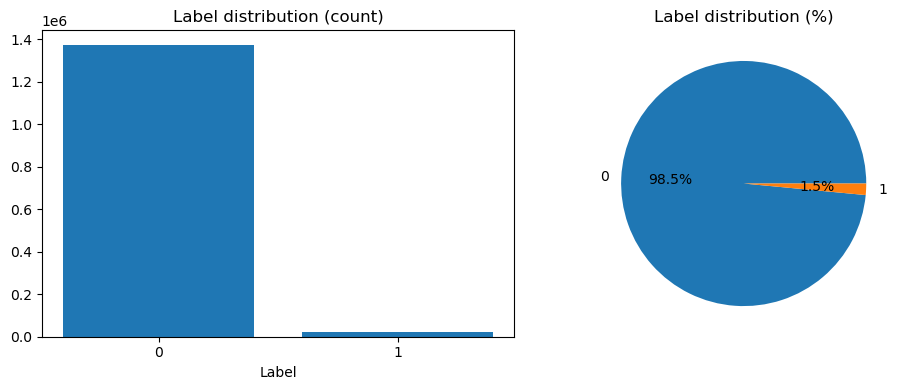

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vc = df['Label'].value_counts()
axes[0].bar(vc.index.astype(str), vc.values)
axes[0].set_title('Label distribution (count)')
axes[0].set_xlabel('Label')

axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%')
axes[1].set_title('Label distribution (%)')

plt.tight_layout()
plt.show()

In [9]:
print('SCAS value counts:')
print(df['SCAS'].value_counts())

SCAS value counts:
SCAS
0    1322652
1      72672
Name: count, dtype: int64


## 4. Temporal Coverage

In [10]:
print(f'Time range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Duration: {df["Timestamp"].max() - df["Timestamp"].min()}')

Time range: 2022-01-20 00:00:03+02:00 → 2022-03-20 23:59:58+02:00
Duration: 59 days 23:59:55


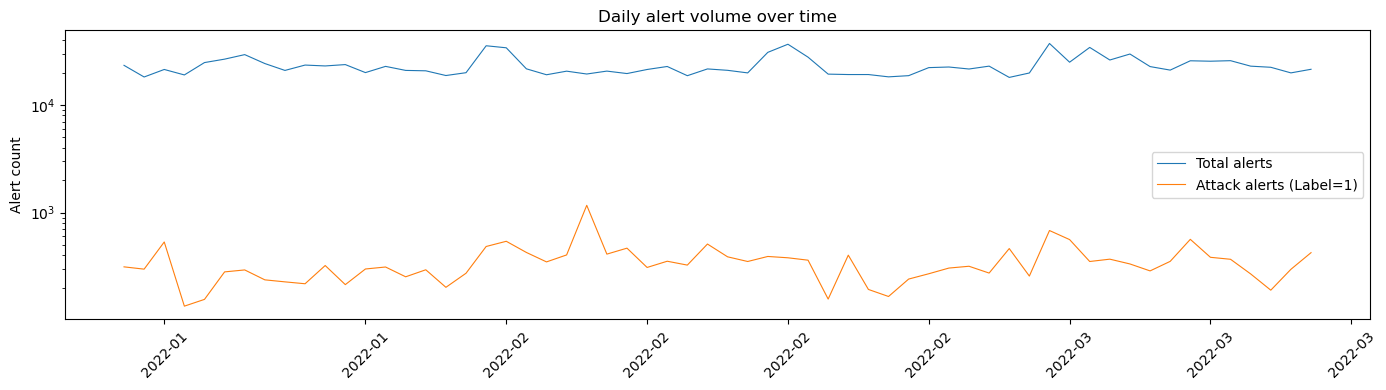

In [11]:
daily = df.set_index('Timestamp').resample('D').agg(
    total=('Label', 'count'),
    attacks=('Label', lambda x: (x == 1).sum())
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['total'], label='Total alerts', linewidth=0.8)
ax.plot(daily.index, daily['attacks'], label='Attack alerts (Label=1)', linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Daily alert volume over time')
ax.set_ylabel('Alert count')
ax.set_yscale('log')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Signature Analysis

In [12]:
print(f'Unique signatures: {df["SignatureID"].nunique()}')
print(f'Unique signature texts: {df["SignatureText"].nunique()}')

# all unique sigs to file for inspection
df[['SignatureID', 'SignatureText']].drop_duplicates().sort_values('SignatureID').to_csv('unique_signatures.csv', index=False) 

Unique signatures: 587
Unique signature texts: 585


In [13]:
top_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).sort_values('count', ascending=False).head(20)

top_sigs['attack_rate%'] = (top_sigs['attack_rate'] * 100).round(3)
top_sigs[['count', 'attacks', 'attack_rate%']]

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2101411,GPL SNMP public access udp,592445,0,0.0
2101616,GPL DNS named version attempt,135622,0,0.0
2101867,GPL RPC xdmcp info query,135350,0,0.0
2842116,ETPRO USER_AGENTS Observed Suspicious UA (Mozilla/5.0),84112,0,0.0
2812543,ETPRO DOS Possible RPC Portmapper Scanning,82503,0,0.0
2101201,GPL WEB_SERVER 403 Forbidden,46384,0,0.0
2808084,ETPRO SNMP R7-2014-02 Ubee cable modem credential stealing attempt 1,35853,0,0.0
2027757,ET DNS Query for .to TLD,33233,0,0.0
2027758,ET DNS Query for .cc TLD,22108,0,0.0


In [14]:
# Top signatures by attack rate (min 10 alerts to filter noise)
all_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).query('count >= 10').sort_values('attack_rate', ascending=False).head(20)

all_sigs['attack_rate%'] = (all_sigs['attack_rate'] * 100).round(1)
all_sigs[['count', 'attacks', 'attack_rate%']]

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2025801,ET EXPLOIT file_put_contents php base64 encoded Remote Code Execution 1,10,10,100.0
2030667,ET WEB_SPECIFIC_APPS vBulletin RCE Inbound (CVE-2019-16759 Bypass),259,259,100.0
2027883,ET EXPLOIT FortiOS SSL VPN - Information Disclosure (CVE-2018-13379),16,16,100.0
2028372,ET JA3 Hash - Possible Malware - FiestaEK,44,44,100.0
2029150,ET JA3 Hash - Trojan.AndroidOS.Jocker.snt 1,64,64,100.0
2029616,ET EXPLOIT Zyxel NAS RCE Attempt Inbound (CVE-2020-9054) M1,160,160,100.0
2029976,ET EXPLOIT Netlink GPON Remote Code Execution Attempt (Inbound),26,26,100.0
2030193,ET WEB_SPECIFIC_APPS Attempted Symantec Secure Web Gateway RCE,64,64,100.0
2030309,ET EXPLOIT Wireless IP Camera (P2) WIFICAM Remote Code Execution,175,175,100.0


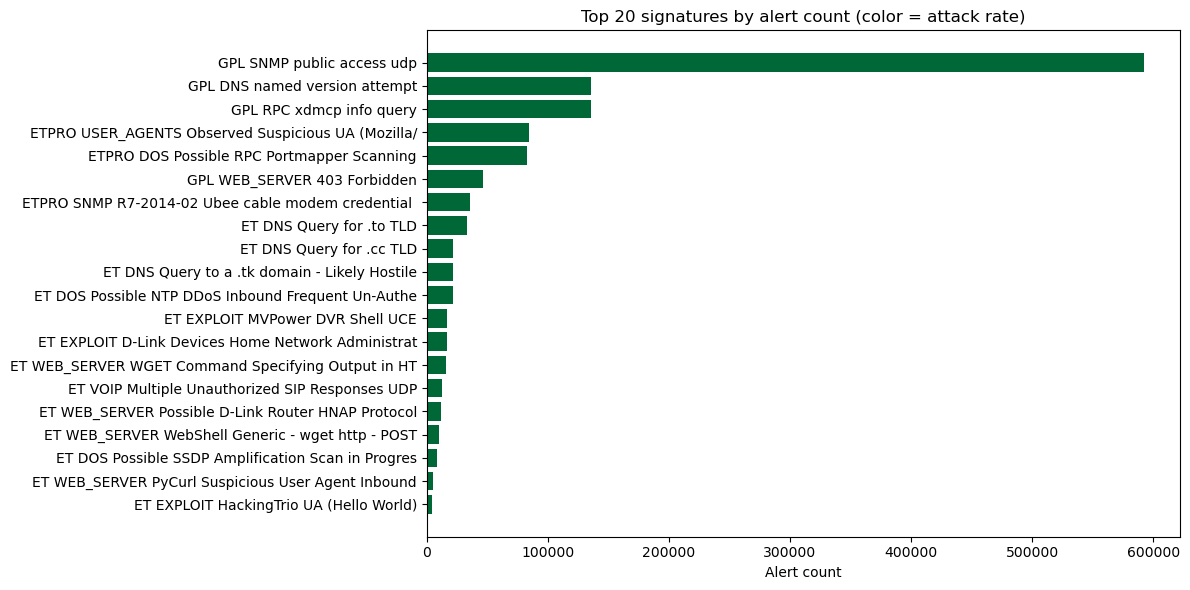

In [15]:
# Top signatures by count, colored by attack rate
top20 = top_sigs.reset_index()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top20['SignatureText'].str[:50], top20['count'], color=plt.cm.RdYlGn_r(top20['attack_rate']))
ax.set_xlabel('Alert count')
ax.set_title('Top 20 signatures by alert count (color = attack rate)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Protocol & Port Distribution

In [16]:
print('Protocol value counts (top 10):')
print(df['Proto'].value_counts().head(10))

Protocol value counts (top 10):
Proto
 17    1128587
 6      266497
-1         129
 1         111
Name: count, dtype: int64


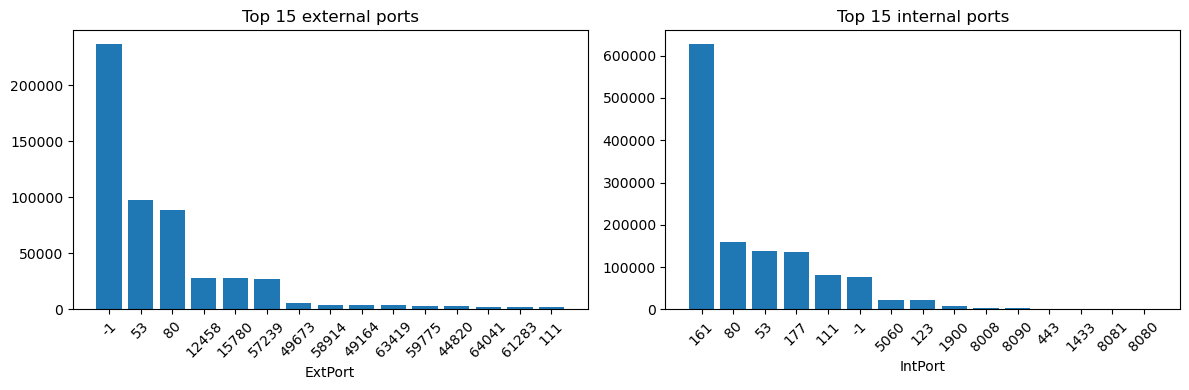

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ExtPort
top_ext = df['ExtPort'].value_counts().head(15)
axes[0].bar(top_ext.index.astype(str), top_ext.values)
axes[0].set_title('Top 15 external ports')
axes[0].set_xlabel('ExtPort')
axes[0].tick_params(axis='x', rotation=45)

# IntPort
top_int = df['IntPort'].value_counts().head(15)
axes[1].bar(top_int.index.astype(str), top_int.values)
axes[1].set_title('Top 15 internal ports')
axes[1].set_xlabel('IntPort')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Similarity Feature Overview

In [18]:
# Replace -1 with NaN for stats on real similarity values
sim_df = df[sim_cols].replace(-1, np.nan)
sim_stats = sim_df.describe().T
sim_stats['coverage%'] = (sim_df.notna().mean() * 100).round(1)
sim_stats[['coverage%', 'mean', 'std', 'min', 'max']].sort_values('coverage%', ascending=False)

,coverage%,mean,std,min,max
Similarity,100.0,0.851473,0.176628,0.0,1.000000
SignatureIDSimilarity,100.0,0.974809,0.145852,0.0,1.000000
ProtoSimilarity,100.0,0.990791,0.067556,0.0,1.000000
IntPortSimilarity,100.0,0.962686,0.162492,0.0,1.000000
IntIPSimilarity,100.0,0.812993,0.352345,0.0,1.000000
AppProtoSimilarity,100.0,0.973877,0.117820,0.0,1.000000
ExtIPSimilarity,100.0,0.651323,0.439495,0.0,1.000000
ExtPortSimilarity,100.0,0.886974,0.304143,0.0,1.000000
HttpRequestBodySimilarity,18.7,0.385069,0.465781,0.0,1.000000
HttpUrlSimilarity,18.7,0.527076,0.394853,0.0,1.000000


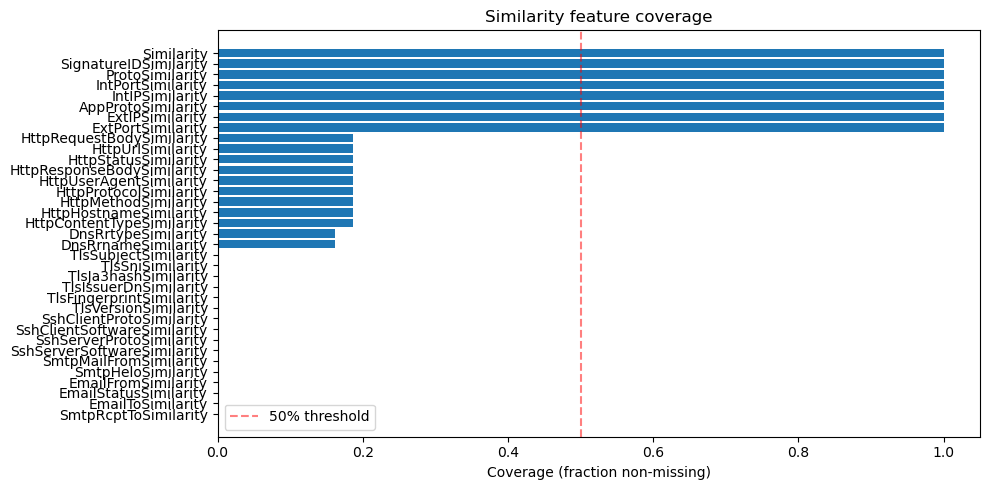

In [19]:
# Coverage heatmap
coverage = sim_df.notna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coverage.index[::-1], coverage.values[::-1])
ax.set_xlabel('Coverage (fraction non-missing)')
ax.set_title('Similarity feature coverage')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

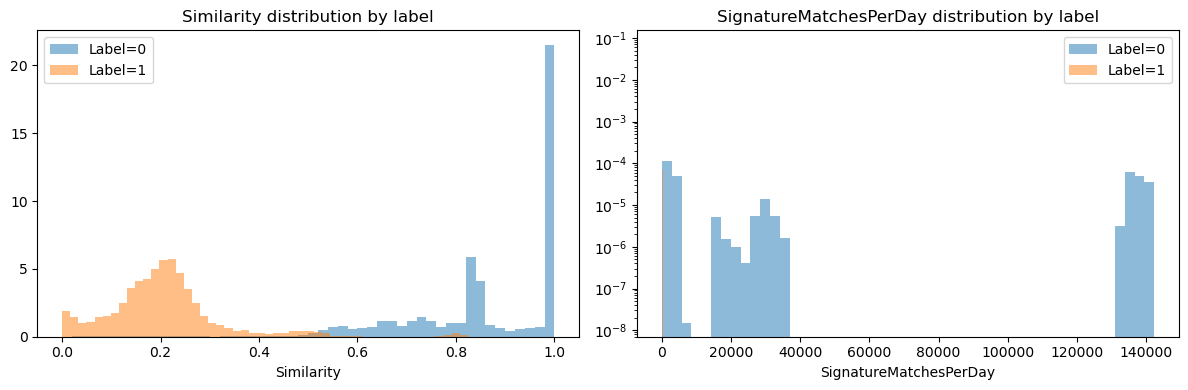

In [20]:
# Distribution of SCAS (aggregate similarity)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby('Label'):
    axes[0].hist(grp['Similarity'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[0].set_title('Similarity distribution by label')
axes[0].set_xlabel('Similarity')
axes[0].legend()

for label, grp in df.groupby('Label'):
    axes[1].hist(grp['SignatureMatchesPerDay'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[1].set_title('SignatureMatchesPerDay distribution by label')
axes[1].set_xlabel('SignatureMatchesPerDay')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Correlation of Similarity Features with Label

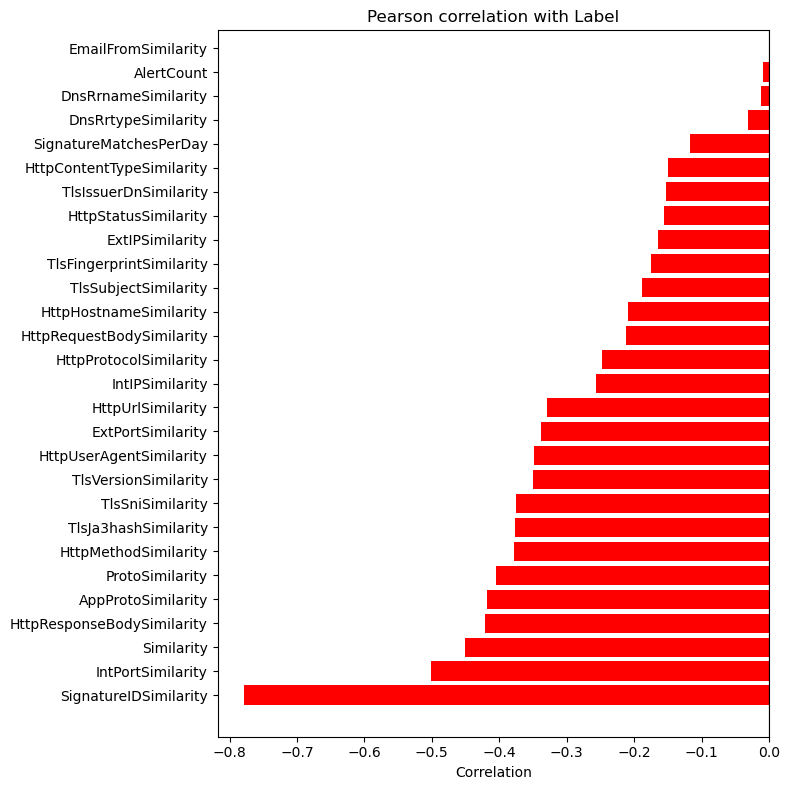

In [21]:
corr_cols = sim_cols + ['Similarity', 'SignatureMatchesPerDay', 'AlertCount']
corr_with_label = df[corr_cols + ['Label']].replace(-1, np.nan).corr()['Label'].drop('Label').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['red' if v < 0 else 'steelblue' for v in corr_with_label.values]
ax.barh(corr_with_label.index, corr_with_label.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with Label')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

## 9. Quick Sanity Checks

In [22]:
print('Duplicate rows:', df.duplicated().sum())
print('Timestamp is monotonic:', df['Timestamp'].is_monotonic_increasing)
print('Unique Label values:', sorted(df['Label'].unique()))
print('Unique SCAS values:', sorted(df['SCAS'].unique()))
print('IntIP unique count (anonymized):', df['IntIP'].nunique())
print('ExtIP unique count (anonymized):', df['ExtIP'].nunique())

Duplicate rows: 0
Timestamp is monotonic: True
Unique Label values: [np.int64(0), np.int64(1)]
Unique SCAS values: [np.int64(0), np.int64(1)]
IntIP unique count (anonymized): 4402
ExtIP unique count (anonymized): 45339


In [23]:
# Rows where IntIP == -1 (not captured)
print('Rows with IntIP == -1:', (df['IntIP'] == '-1').sum())

Rows with IntIP == -1: 330352


## 10. Tokenization

In [24]:
from thesis.preprocessing.suricata_tokenization import tokenize_signatures_df

df = pd.read_csv('unique_signatures.csv')
results = tokenize_signatures_df(df)

df_out = pd.DataFrame([
    {
        "signature_id": s.signature_id,
        "ruleset": s.ruleset,
        "category": s.category,
        "description": s.description,
        "cve_refs": "|".join(sorted(s.cve_refs)),
        "qualifiers": "|".join(sorted(s.qualifiers)),
        "tokens": "|".join(sorted(s.tokens)),
    }
    for s in results
])

df_out.to_csv("tokenized_signatures2.csv", index=False)
